### Author: Allan R. Jeeboo 
### Preferred Name: Vyncent S. A. van der Wolvenhuizen 
### Affiliation: Data Science Student at TripleTen 
### Email: vanderwolvenhuizen.vyncent@proton.me 
### Date started: 2025-04-05 
### Last updated: 2025-04-08 19:56

# 1.0 Introduction 
For this project, we'll be assuming the role of a data scientist at the OilyGiant mining company. Our task is to find the best place for a new well.

Steps to choose the location:

 1. Collect the oil well parameters in the selected region: oil quality and volume of reserves. 
 2. Build a model for predicting the volume of reserves in the new wells. 
 3. Pick the oil wells with the highest estimated values.
 4. Pick the region with the highest total profit for the selected oil wells. 
We have data on oil samples from three regions. Parameters of each oil well in the region are already known. We'll build a model that will help to pick the region with the highest profit margin, then analyze potential profit and risks using the Bootstrapping technique.

Workflow Path: 
 1. **Data Import and Overview**: We will begin by importing the dataset and conducting a preliminary exploration.
 2. **Data Cleaning and Preprocessing**: Next, we will clean the data, standardize column names, and address any inconsistencies or redundancies.
 3. **Exploratory Data Analysis (EDA)**: We will analyze the data to uncover patterns and relationships that may influence customer behavior. 
 
Train and test the model for each region:
 2.1. Split the data into a training set and validation set at a ratio of 75:25.
 2.2. Train the model and make predictions for the validation set.
 2.3. Save the predictions and correct answers for the validation set.
 2.4. Print the average volume of predicted reserves and model RMSE.
 2.5. Analyze the results.
Prepare for profit calculation:
 3.1. Store all key values for calculations in separate variables.
 3.2. Calculate the volume of reserves sufficient for developing a new well without losses. Compare the obtained value with the average volume of reserves in each region.
 3.3. Provide the findings about the preparation for profit calculation step.
Write a function to calculate profit from a set of selected oil wells and model predictions:
 4.1. Pick the wells with the highest values of predictions. 
 4.2. Summarize the target volume of reserves in accordance with these predictions
 4.3. Provide findings: suggest a region for oil wells' development and justify the choice. Calculate the profit for the obtained volume of reserves.
Calculate risks and profit for each region:
     5.1. Use the bootstrapping technique with 1000 samples to find the distribution of profit.
     5.2. Find average profit, 95% confidence interval and risk of losses. Loss is negative profit, calculate it as a probability and then express as a percentage.
     5.3. Provide findings: suggest a region for development of oil wells and justify the choice. 

All of the information used throughout Section 1 comes from TripleTen's Sprint 9 [project overview](https://tripleten.com/trainer/data-scientist/lesson/676da3d0-d254-4f97-bec8-7178b52f9ff9/) page.

### 1.1 Data Import & Overview

In [52]:
import pandas as pd 
import math
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, train_test_split

geo_0 = pd.read_csv('geo_data_0.csv')
geo_1 = pd.read_csv('geo_data_1.csv')
geo_2 = pd.read_csv('geo_data_2.csv')

display('Geo 0:', geo_0.head(), f'rows, columns: {geo_0.shape}')
display('Geo 1:', geo_1.head(), f'rows, columns: {geo_1.shape}')
display('Geo 2:', geo_2.head(), f'rows, columns: {geo_2.shape}')

'Geo 0:'

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


'rows, columns: (100000, 5)'

'Geo 1:'

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


'rows, columns: (100000, 5)'

'Geo 2:'

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


'rows, columns: (100000, 5)'

In [53]:
print(geo_0.info())
print() 
print(geo_1.info())
print()
print(geo_2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column

### 1.2 Data Description

Geological exploration data for the three regions are stored in files:

1. geo_data_0.csv. download dataset
2. geo_data_1.csv. download dataset
3. geo_data_2.csv. download dataset

Column descriptions: 
- **id**: unique oil well identifier  

- **f0**, **f1**, **f2**: three features of points (their specific meaning is unimportant, but the features themselves are significant)  

- **product**: volume of reserves in the oil well (thousand barrels).  

Conditions:

1. Only linear regression is suitable for model training (the rest are not sufficiently predictable).
2. When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
3. The budget for development of 200 oil wells is 100 USD million.
4. One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
5. After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.
6. The data is synthetic: contract details and well characteristics are not disclosed.

# 2.0 Data Preprocessing 
Before we move on to EDA, we need to preprocess the data. Our columns are already formatted properly, so now we need to check for nans and duplicates. If there are any, we'll address them; otherwise, we'll continue to EDA.

### 2.1 NaNs

In [54]:
print(f'geo_0 nans:\n{geo_0.isna().sum()}\n\n', 
      f'geo_1 nans:\n{geo_1.isna().sum()}\n\n', 
      f'geo_2 nans:\n{geo_2.isna().sum()}')

geo_0 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_1 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64

 geo_2 nans:
id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


No nans. Nice.

### 2.2 Duplicates

In [55]:
print(f'geo_0 duplicates:{geo_0.duplicated().sum()}\n', 
      f'geo_1 duplicates:{geo_1.duplicated().sum()}\n', 
      f'geo_2 duplicates:{geo_2.duplicated().sum()}')

geo_0 duplicates:0
 geo_1 duplicates:0
 geo_2 duplicates:0


In [56]:
print(f'geo 0 duplicate ids:\n{geo_0['id'].duplicated().sum()}\n', 
      f'geo 1 duplicate ids:\n{geo_1['id'].duplicated().sum()}\n', 
      f'geo 2 duplicate ids:\n{geo_2['id'].duplicated().sum()}') 

geo 0 duplicate ids:
10
 geo 1 duplicate ids:
4
 geo 2 duplicate ids:
4


In [57]:
#geo_0, geo_1, geo_2 = geo_0['id'].drop_duplicates(), geo_1['id'].drop_duplicates(), geo_2['id'].drop_duplicates()

#print(geo_0.shape, 
#      geo_1.shape, 
#geo_2.shape)

There aren't any duplicate rows, but in the `id` column of all three data sets, there are missing values - ten, four, and four respectively.

# 3.0 EDA 
In this section we'll explore the data and create visuals to see what information we can gather. Remember our target is the `product` column. Because the `id` column will interfere 

### 3.1 Geo 0

In [58]:
display(geo_0.head())
print(f'Rows, columns:\n{geo_0.shape}') 

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


Rows, columns:
(100000, 5)


In [59]:
print(f'Geo 0 description:\n{geo_0.describe()}\n\n', 
      f'Geo 1 description:\n{geo_1.describe()}\n\n', 
      f'Geo 2 description:\n{geo_2.describe()}\n\n') 

Geo 0 description:
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        0.500419       0.250143       2.502647      92.500000
std         0.871832       0.504433       3.248248      44.288691
min        -1.408605      -0.848218     -12.088328       0.000000
25%        -0.072580      -0.200881       0.287748      56.497507
50%         0.502360       0.250252       2.515969      91.849972
75%         1.073581       0.700646       4.715088     128.564089
max         2.362331       1.343769      16.003790     185.364347

 Geo 1 description:
                  f0             f1             f2        product
count  100000.000000  100000.000000  100000.000000  100000.000000
mean        1.141296      -4.796579       2.494541      68.825000
std         8.965932       5.119872       1.703572      45.944423
min       -31.609576     -26.358598      -0.018144       0.000000
25%        -6.298551      -8.267985 

In [60]:
geo_0_corr = {col: geo_0['product'].corr(geo_0[col]) for col in ['f0', 'f1', 'f2']}
print(geo_0_corr)

{'f0': np.float64(0.1435363509318926), 'f1': np.float64(-0.19235576281513295), 'f2': np.float64(0.4836632869261522)}


Text(0, 0.5, 'Frequency')

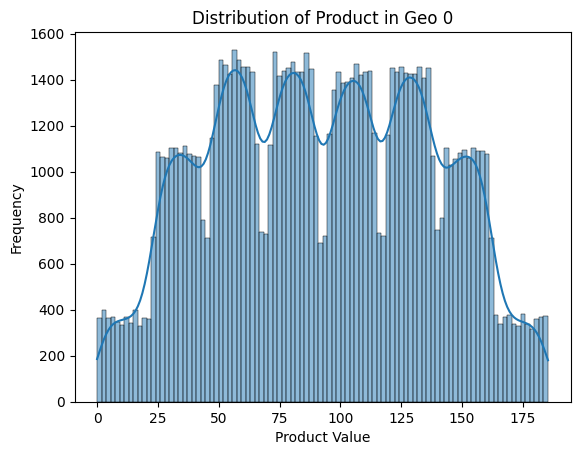

In [61]:
sns.histplot(data= geo_0, 
             bins= 100, 
             x= 'product', 
             kde= True) 

plt.title('Distribution of Product in Geo 0') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency')

### 3.2 Geo 1

What's going on here? This is an odd distribution. It looks like multiple small bell curves within a larger bell curve.

In [62]:
geo_1_corr = {col: geo_1['product'].corr(geo_1[col]) for col in ['f0', 'f1', 'f2']}
print(geo_1_corr)

{'f0': np.float64(-0.030490530564375215), 'f1': np.float64(-0.010154931786466105), 'f2': np.float64(0.9993969704906549)}


Text(0, 0.5, 'Frequency')

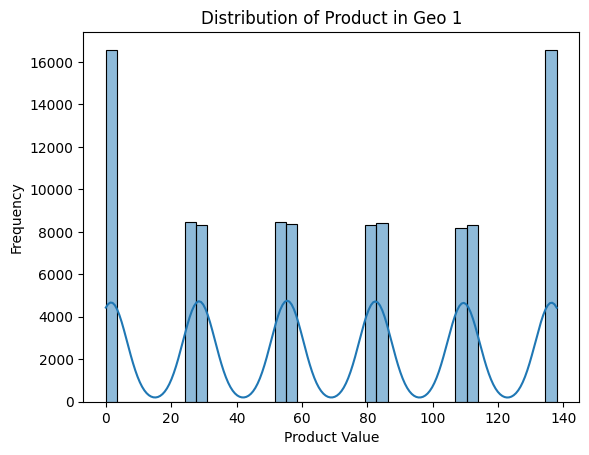

In [63]:
sns.histplot(data= geo_1, 
             x= 'product', 
             kde= True) 
plt.title('Distribution of Product in Geo 1') 
plt.xlabel('Product Value') 
plt.ylabel('Frequency') 

### 3.3 Geo 2

In [64]:
geo_2_corr = {col: geo_2['product'].corr(geo_2[col]) for col in ['f0', 'f1', 'f2']}
print(geo_2_corr)

{'f0': np.float64(-0.0019870619990491364), 'f1': np.float64(-0.0010123938161309004), 'f2': np.float64(0.445871091557421)}


Text(0, 0.5, 'Frequency')

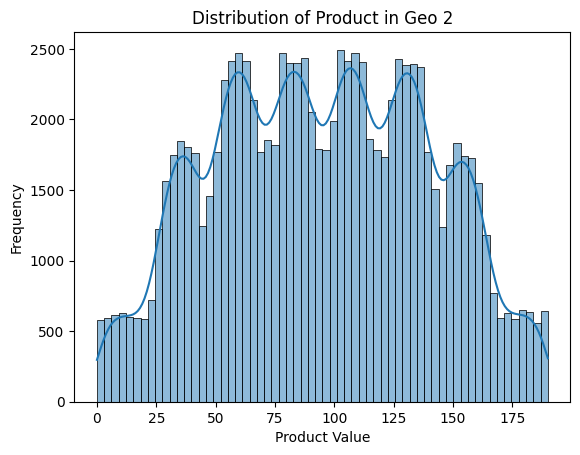

In [65]:
sns.histplot(data= geo_2, 
             x= 'product', 
             kde= True, ) 
plt.title('Distribution of Product in Geo 2')
plt.xlabel('Product Value')
plt.ylabel('Frequency')

# 4.0 Model creation 

In [66]:
region_0 = geo_0.drop(columns= ['id'])
region_1 = geo_1.drop(columns= ['id'])
region_2 = geo_2.drop(columns= ['id'])

### 4.1. Geo 0 Model

In [ ]:
features_0 = region_0.drop(columns= ['product'])
target_0 = region_0['product']

features_0_train, features_0_valid, target_0_train, target_0_valid = train_test_split(features_0, 
                                                                                      target_0, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= 12345)

model_0 = LinearRegression()
model_0.fit(features_0_train, target_0_train) 
predictions_0 = model_0.predict(features_0_valid)

target_0_valid
predictions_0

predictions_0 = pd.DataFrame(predictions_0, 
                             columns= ['product']) 
for i in range


cross_val_scores_0 = cross_val_score(model_0, 
                                     features_0_train, 
                                     target_0_train, 
                                     cv= 8) 

print(cross_val_scores_0) 
print(features_0_train.shape, target_0_train.shape, 
      features_0_valid.shape, target_0_valid.shape)

[0.27096805 0.26712777 0.27103073 0.28781954 0.27614261 0.27439636
 0.27060832 0.2751891 ]
(75000, 3) (75000,) (25000, 3) (25000,)


In [68]:
predictions_0 = model_0.predict(features_0_valid)
predictions_0_mean = predictions_0.mean()

print(f'Predictions:\n{predictions_0},\n\n'f'Avg predicted volume: {predictions_0_mean}')

Predictions:
[ 95.89495185  77.57258261  77.89263965 ...  61.50983303 118.18039721
 118.16939229],

Avg predicted volume: 92.59256778438035


In [69]:
print(f'Average cross-validation score for Geo 0: {cross_val_scores_0.mean()}')

Average cross-validation score for Geo 0: 0.2741603097775681


In [70]:
rmse_0 = mean_squared_error(target_0_valid, predictions_0) ** 0.5 

print(f'RMSE for Geo 0: {rmse_0}')

RMSE for Geo 0: 37.5794217150813


### 4.2 Geo 1 Model

In [71]:
features_1 = region_1.drop(columns= ['product']) 
target_1 = region_1['product'] 

features_1_train, features_1_valid, target_1_train, target_1_valid = train_test_split(features_1, 
                                                                                      target_1, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= 12345) 

model_1 = LinearRegression()
model_1.fit(features_1_train, target_1_train)
 
cross_val_scores_1 = cross_val_score(model_1, 
                                     features_1_train, 
                                     target_1_train, 
                                     cv= 8) 

In [72]:
predictions_1 = model_1.predict(features_1_valid)
predictions_1_mean = predictions_1.mean()

print(f'Predictions:\n{predictions_1},\n\n'f'Avg predicted volume: {predictions_1_mean}')

Predictions:
[ 82.66331365  54.43178616  29.74875995 ... 137.87934053  83.76196568
  53.95846638],

Avg predicted volume: 68.72854689544602


In [73]:
print(f'Average mean cross-validation score for Geo 1: {cross_val_scores_1.mean()}')

Average mean cross-validation score for Geo 1: 0.9996247090042585


In [74]:
rmse_1 = mean_squared_error(target_1_valid, predictions_1) ** 0.5 

print(f'RMSE for Geo 1: {rmse_1}')

RMSE for Geo 1: 0.8930992867756165


### 4.3 Geo 2 Model

In [75]:
features_2 = region_2.drop(columns= ['product']) 
target_2 = region_2['product'] 

features_2_train, features_2_valid, target_2_train, target_2_valid = train_test_split(features_2, 
                                                                                      target_2, 
                                                                                      test_size= 0.25, 
                                                                                      random_state= 12345) 

model_2 = LinearRegression() 
model_2.fit(features_2_train, target_2_train) 
cross_val_scores_2 = cross_val_score(model_2, 
                                     features_2_train, 
                                     target_2_train, 
                                     cv= 8) 

In [76]:
predictions_2 = model_2.predict(features_2_valid)
predictions_2_mean = model_2.predict(features_2_valid).mean() 

print(f'Predictions:\n{predictions_2},\n\n'f'Avg predicted volume: {predictions_2_mean}')

Predictions:
[ 93.59963303  75.10515854  90.06680936 ...  99.40728116  77.77991248
 129.03241718],

Avg predicted volume: 94.96504596800489


In [77]:
print(f'Average mean cross-validation score for Geo 1: {cross_val_scores_1.mean()}')

Average mean cross-validation score for Geo 1: 0.9996247090042585


In [78]:
predictions_2_valid = model_2.predict(features_2_valid)
rmse_2 = mean_squared_error(target_2_valid, predictions_2_valid) ** 0.5 

print(f'RMSE for Geo 2: {rmse_2}') 

RMSE for Geo 2: 40.02970873393434


# 5.0 Profit Calculation

In [86]:
budget = 10**8 
revenue_per_unit = 4500
num_of_wells = 200 
price_per_point = budget // num_of_wells
print(f'Price per point: ${price_per_point}')

Price per point: $500000


Average revenue per well in a region:

In [79]:
geo_0['product'].mean() * 4500

np.float64(416250.00000000006)

In [80]:
geo_1['product'].mean() * 4500

np.float64(309712.50000000006)

In [81]:
geo_2['product'].mean() * 4500

np.float64(427500.0000000002)

In [82]:
geo_0.shape

(100000, 5)

In [90]:
print(f'Volume of reserves in thousands of barrels needed to break even:\n{price_per_point / revenue_per_unit}')

Volume of reserves in thousands of barrels needed to break even:
111.11111111111111
